# MSE StatDig : Chap 8 "Spectrum estimation""
## Ex 8.1 Periodogram and modified periodogram
ver : DLY/31.05.2026

## General

### Description

The resolution of the periodogram, i.e. its ability to resolve closely spaced narrowband components is limited because of the Bartlett window.  
Since the width of the main lobe increases as N decreases, for a given N there is a limit on how closely two sinusoids may be located before they can no longer be resolved.  
This is usually defined as the bandwidth of the window at its half power points (-6dB), which is for the Bartlett window at:

$$Res\{\hat{P}_{per}(e^{j\omega})\} = 0.89 \frac{2\pi}{N}$$

This relation is valid for $\omega \in [-\pi...\pi]$.  
In the frequency domain, $f \in [-Fe/2...Fe/2]$, the bandwidth of the window at its half power points (-6dB) is:

$$Res\{\hat{P}_{per}(e^{j\omega})\} = 0.89 \frac{Fe}{N}$$

---

### Example:

Let's take an example where N is too low to separate 2 close sinusoids.  
In this example, the signal is a mixture of 2 sinusoids with $\omega = [0.4\pi, 0.45\pi]$, with random phase and added Gaussian noise `v[n]` 
(with $\mu = 0$, $\sigma = 5$):

$$x[n] = A_1 sin(n\omega_1 + \phi_1) + A_2 \sin(n\omega_2 + \phi_2) + v[n]$$

To evaluate the effect on the resolution, the number of points $N$ will be changed:  $N = [32; 128]$

The process must be realized `Nr = 50` times.

### Work

#### Ex1 : Periodogram
##### Ex1.1 : Signal generation

- Generate the random process signals with N = 32 and N = 128 for Nr = 50
- Plot the signals in the time domain

For the generation of the signal, you can use the following code:

```python
import numpy as np
import matplotlib.pyplot as plt

Npoints = np.array([32,128])
omegas = np.array([0.4*np.pi,0.45*np.pi])
sigmaV = 5
As = [5, 5]
Nr = 50
NFFT = 512
NFFT2 = int(NFFT/2)

np.random.seed(0)

xn_all = []
for i in range(len(Npoints)):
    N = Npoints[i]
    n = np.arange(N)[:,None]
    nn = np.repeat(n,Nr,1).T
    
    v = sigmaV*np.random.randn(Nr,N)
    Phi = np.random.rand(Nr,len(omegas)) * np.pi - np.pi
    x = v.copy()
    for k in range(len(omegas)):
        x += As[k]*np.sin(nn*omegas[k]+Phi[:,k][:,None])
    xn_all.append(x)

```


In [36]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt
from scipy.fft import fft, fftfreq

In [37]:
Npoints = np.array([32,128])
omegas = np.array([0.4*np.pi,0.45*np.pi])
sigmaV = 5
As = [5, 5]
Nr = 50
NFFT = 512
NFFT2 = int(NFFT/2)

np.random.seed(0)

xn_all = []
for i in range(len(Npoints)):
    N = Npoints[i]
    n = np.arange(N)[:,None]
    nn = np.repeat(n,Nr,1).T
    
    v = sigmaV*np.random.randn(Nr,N)
    Phi = np.random.rand(Nr,len(omegas)) * np.pi - np.pi
    x = v.copy()
    for k in range(len(omegas)):
        x += As[k]*np.sin(nn*omegas[k]+Phi[:,k][:,None])
    xn_all.append(x)

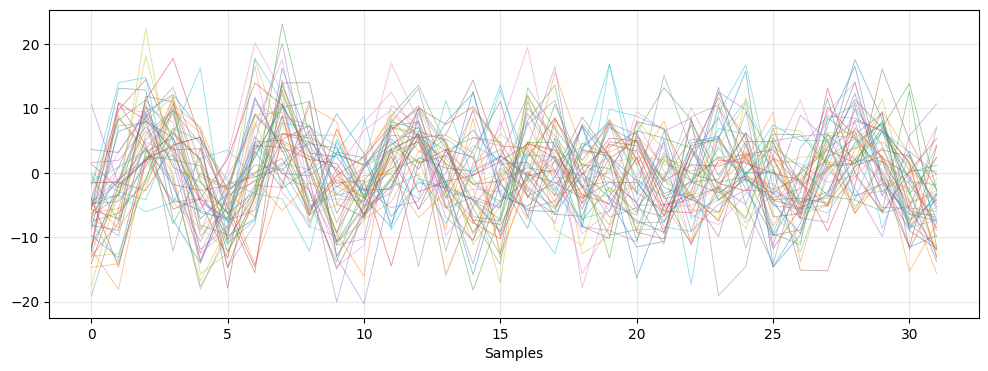

In [38]:
x = xn_all[0]  # shape (Nr, N)

fig, ax = plt.subplots(figsize=(12, 4))

for i in range(Nr):
    ax.plot(x[i], linewidth=0.6, alpha=0.5)

ax.set_xlabel("Samples")
ax.grid(True, alpha=0.3)
plt.show()

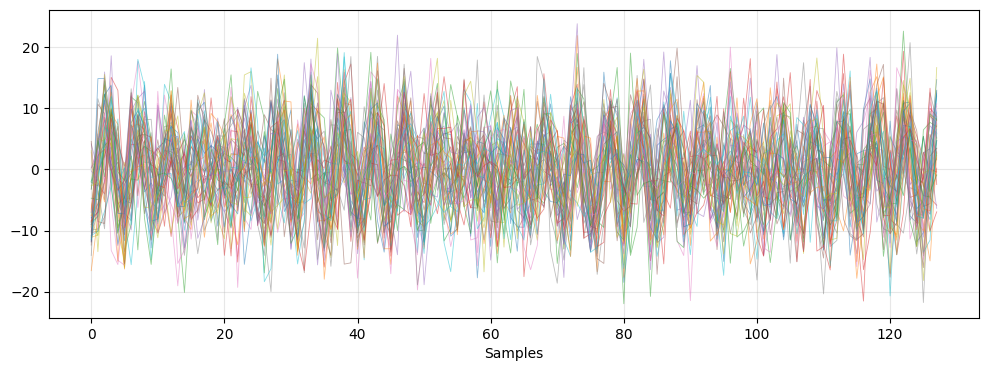

In [39]:
x = xn_all[1]  # shape (Nr, N)

fig, ax = plt.subplots(figsize=(12, 4))
for i in range(Nr):
    ax.plot(x[i], linewidth=0.6, alpha=0.5)

ax.set_xlabel("Samples")
ax.grid(True, alpha=0.3)
plt.show()

##### Ex1.2 : Periodogram computation

The goal is now to compute the periodogram for each realization of each random process and to display it.

Your work :

- Implement the function `myPer` which computes the periodogram of a signal.
```python

def myPer(x, NFFT):
    '''
    MYPER	Estimate the spectrum of a process using the periodogram
    USAGE	Px = myPer(x,NFFT)
        The spectrum of a process x is estimated using the periodogram.
    INPUT:
        x    :(N,)  input sequence
        NFFT : scalar  number of points used for the DTFT
    OUTPUT:
        Px  : (Nfft,) The periodogram is returned in Px using a linear scale.
    '''

    # YOUR CODE HERE

    return Px

```

- Display each periodogram on two separates figures (one for each N).
- Display the average periodogram of each realization on two separates figure (one for each N).

In [40]:
def myPer(x, NFFT):
    '''
    MYPER	Estimate the spectrum of a process using the periodogram
    USAGE	Px = myPer(x,NFFT)
        The spectrum of a process x is estimated using the periodogram.
    INPUT:
        x    :(N,)  input sequence
        NFFT : scalar  number of points used for the DTFT
    OUTPUT:
        Px  : (Nfft,) The periodogram is returned in Px using a linear scale.
    '''
    N = len(x)
    x_fft = np.fft.fft(x, n= NFFT)
    x_fft_module = np.abs(x_fft)
    Px = (x_fft_module**2)/N

    return Px

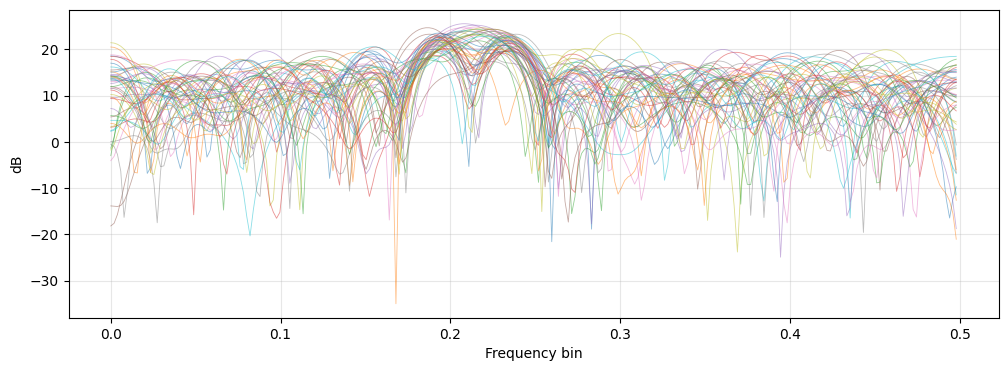

In [41]:
# px_all is a 2D matrix (50 rows for realizations, NFFT columns for frequencies)
px_all = myPer(xn_all[0], NFFT)
# Create an array from 0 to NFFT-1
freq_bins = np.arange(NFFT)

# Normalize to get frequencies from 0.0 to 1.0
freq_norm = freq_bins / NFFT
# Calculate the middle index (integer division)
nyquist_idx = NFFT // 2

# Slice to keep only the first half (0.0 to 0.5)
freq_half = freq_norm[:nyquist_idx]
fig, ax = plt.subplots(figsize=(12, 4))

for i in range(Nr):
    # 1. Extract the current realization and slice it to the Nyquist limit
    px_single_half = px_all[i, :nyquist_idx]
    
    # 2. Convert to dB
    px_db = 10 * np.log10(px_single_half)
    
    # 3. Plot with X and Y arrays of the exact same size
    ax.plot(freq_half, px_db, linewidth=0.6, alpha=0.5)

ax.set_xlabel("Frequency bin")
ax.set_ylabel("dB")
ax.grid(True, alpha=0.3)
plt.show()

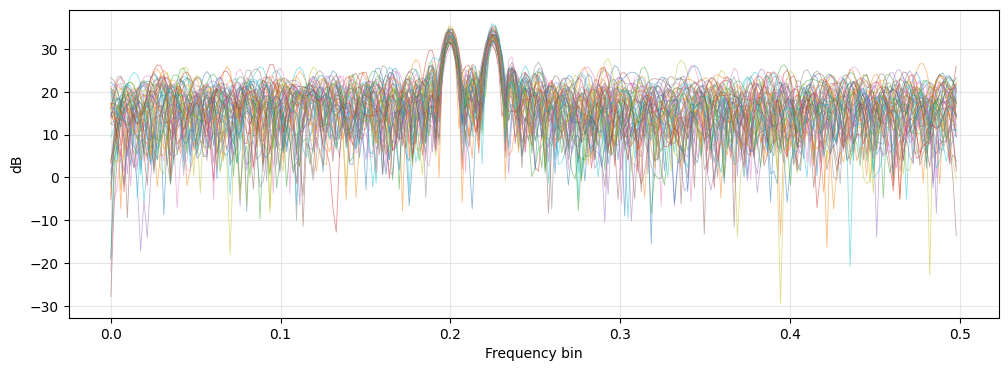

In [42]:
# px_all is a 2D matrix (50 rows for realizations, NFFT columns for frequencies)
px_all = myPer(xn_all[1], NFFT)
# Create an array from 0 to NFFT-1
freq_bins = np.arange(NFFT)

# Normalize to get frequencies from 0.0 to 1.0
freq_norm = freq_bins / NFFT
# Calculate the middle index (integer division)
nyquist_idx = NFFT // 2

# Slice to keep only the first half (0.0 to 0.5)
freq_half = freq_norm[:nyquist_idx]
fig, ax = plt.subplots(figsize=(12, 4))

for i in range(Nr):
    # 1. Extract the current realization and slice it to the Nyquist limit
    px_single_half = px_all[i, :nyquist_idx]
    
    # 2. Convert to dB
    px_db = 10 * np.log10(px_single_half)
    
    # 3. Plot with X and Y arrays of the exact same size
    ax.plot(freq_half, px_db, linewidth=0.6, alpha=0.5)

ax.set_xlabel("Frequency bin")
ax.set_ylabel("dB")
ax.grid(True, alpha=0.3)
plt.show()

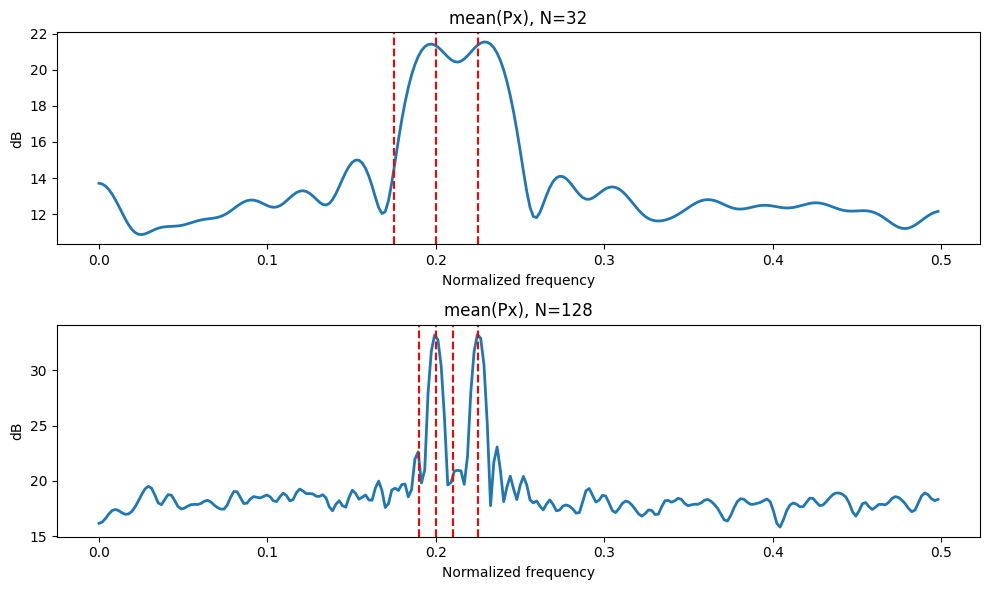

In [43]:
# ==========================================
# Processing for N = 32
# ==========================================

# 1. Compute the 50 periodograms at once (vectorized)
px_all_32 = myPer(xn_all[0], NFFT) 

# 2. Compute the mean across the 50 realizations (average the rows)
px_mean_32 = np.mean(px_all_32, axis=0)

# 3. Slice to Nyquist frequency and convert to dB
px_mean_32_db = 10 * np.log10(px_mean_32[:nyquist_idx])

# ==========================================
# Processing for N = 128
# ==========================================

# Repeat the exact same logic for the second dataset
px_all_128 = myPer(xn_all[1], NFFT) 
px_mean_128 = np.mean(px_all_128, axis=0)
px_mean_128_db = 10 * np.log10(px_mean_128[:nyquist_idx])

# ==========================================
# Plotting the results
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# --- Top Plot: N = 32 ---
ax1.plot(freq_half, px_mean_32_db, linewidth=2)
ax1.set_title("mean(Px), N=32")
ax1.set_ylabel("dB")
ax1.set_xlabel("Normalized frequency")

# Add vertical lines for theoretical frequencies and resolution limits
ax1.axvline(x=0.2, color='r', linestyle='--')
ax1.axvline(x=0.225, color='r', linestyle='--')
ax1.axvline(x=0.175, color='r', linestyle='--') 

# --- Bottom Plot: N = 128 ---
ax2.plot(freq_half, px_mean_128_db, linewidth=2)
ax2.set_title("mean(Px), N=128")
ax2.set_ylabel("dB")
ax2.set_xlabel("Normalized frequency")

# Add vertical lines for theoretical frequencies
ax2.axvline(x=0.2, color='r', linestyle='--')
ax2.axvline(x=0.225, color='r', linestyle='--')
ax2.axvline(x=0.19, color='r', linestyle='--')
ax2.axvline(x=0.21, color='r', linestyle='--')

plt.tight_layout()
plt.show()

#### Ex2 : Modified Periodogram
Instead of applying a rectangular window to x[n] to make it finite length, other kind of windows could be used.
This degree of freedom can be used to modulate the amount of smoothing to be applied to the periodogram. Although a rectangular window has a narrow main lobe compared to other windows and therefore, produces the least amount of spectral smoothing, it has relatively large sidelobes that may lead to the masking of weak narrowband components.



##### Ex2.1 : Signal generation

Lets start to generate the same process than before but with different values: $\omega=[0.25\pi, 0.3\pi]$ with random phase and with added Gaussian noise v[n] ($\mu = 0, \sigma=0.3$)

$$x[n] = A_1 sin(n\omega_1 + \phi_1) + A_2 \sin(n\omega_2 + \phi_2) + v[n]$$

Where the amplitude is $A_1=0.1$ and $A_2=1$. Only N=256 samples are generated for each of the 20 realizations.

- Display each realization of the random process in the time domain on a single figure.

```python
A = [0.1, 1]
N3 = 256
Nr = 20
n3 = np.arange(N3)
NFFT = 2048
NFFT2 = int(NFFT//2)
sigmaV = .3
omega = np.array([.25, .3]) * np.pi

n = np.arange(N3)[:,None]
nn = np.repeat(n,Nr,1).T

V3   = sigmaV * sigmaV*np.random.randn(Nr,N3)
Phi3 = np.random.rand(Nr,2) * np.pi - np.pi
x3 = A[0] * np.sin(nn*omega[0]+Phi3[:,0][:,None])+A[1]*np.sin(nn*omega[1]+Phi3[:,1][:,None]) + V3
```

In [44]:
A = [0.1, 1]
N3 = 256
Nr = 20
n3 = np.arange(N3)
NFFT = 2048
NFFT2 = int(NFFT//2)
sigmaV = .3
omega = np.array([.25, .3]) * np.pi

n = np.arange(N3)[:,None]
nn = np.repeat(n,Nr,1).T

V3   = sigmaV * sigmaV*np.random.randn(Nr,N3)
Phi3 = np.random.rand(Nr,2) * np.pi - np.pi
x3 = A[0] * np.sin(nn*omega[0]+Phi3[:,0][:,None])+A[1]*np.sin(nn*omega[1]+Phi3[:,1][:,None]) + V3

print(x3.shape)

(20, 256)


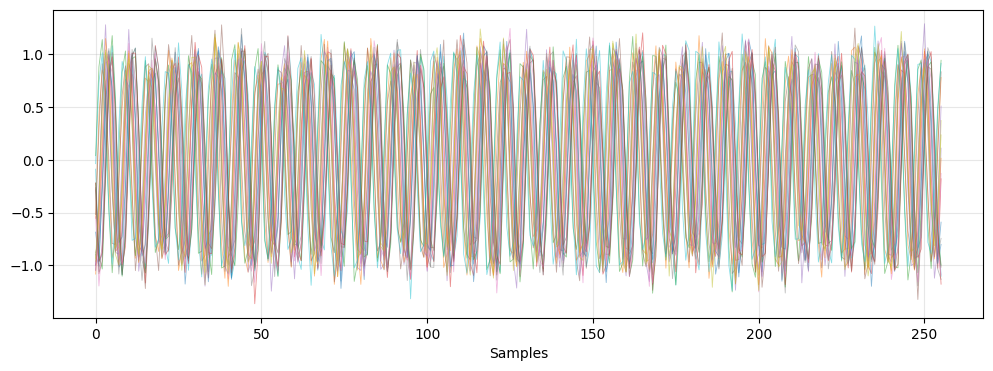

In [45]:
fig, ax = plt.subplots(figsize=(12, 4))


ax.plot(x3.T, linewidth=0.6, alpha=0.5)

ax.set_xlabel("Samples")
ax.grid(True, alpha=0.3)
plt.show()

##### Ex2.2 : Windows analysis
The modified periodogram can use different windows. For this example, we will use only  hamming window instead of the rectangular window. As the spectrum will be a convolution with the square fourier transform of the window, it is interesting to look the window spectrum. To achieve that:

- Create the rectangular and hamming windows using N points
- Normalize each window by their respective rms value
- Compute the DTFT using NFFT points
- Display each window in the time domain and the DTFT of each window in the frequency domain

The rectangular window is easily computed using np.ones((N)). The hamming window is easily generated with wh=hamming(N). Below, the two windows are compared:

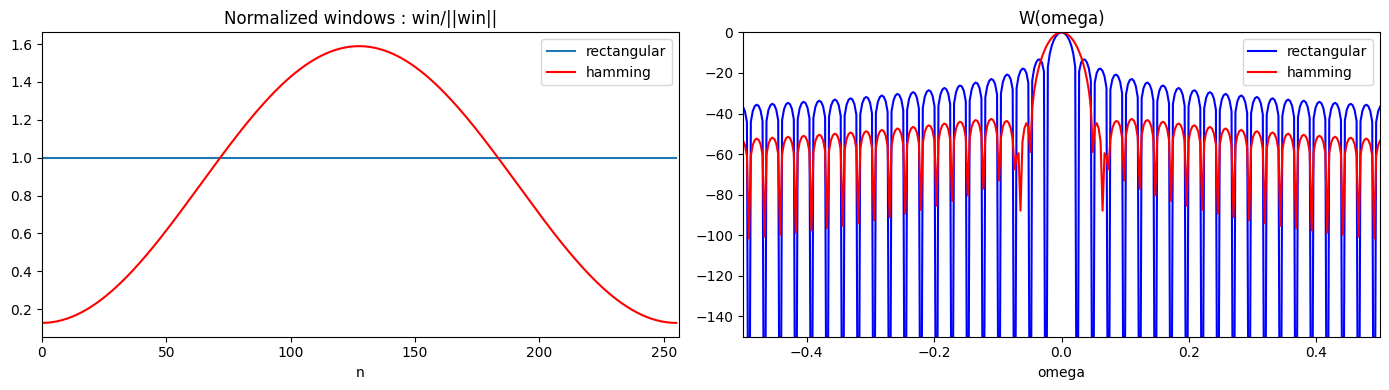

In [48]:
# 1. Création des fenêtres avec ta variable N3 (256)
w_rect = np.ones(N3)
w_hamm = signal.windows.hamming(N3) 

# 2. Normalisation par la valeur RMS
rms_rect = np.sqrt(np.mean(w_rect**2))
rms_hamm = np.sqrt(np.mean(w_hamm**2))

w_rect_norm = w_rect / rms_rect
w_hamm_norm = w_hamm / rms_hamm

# 3. Calcul de la DTFT 
W_rect = np.fft.fftshift(fft(w_rect_norm, NFFT))
W_hamm = np.fft.fftshift(fft(w_hamm_norm, NFFT))

# LA CORRECTION EST ICI : on multiplie par 2*pi pour avoir des radians
omega = np.fft.fftshift(fftfreq(NFFT)) * 2 * np.pi

# 4. Conversion en dB 
W_rect_dB = 20 * np.log10(np.abs(W_rect) + 1e-12)
W_hamm_dB = 20 * np.log10(np.abs(W_hamm) + 1e-12)

# Normalisation pour que le maximum soit à 0 dB
W_rect_dB -= np.max(W_rect_dB)
W_hamm_dB -= np.max(W_hamm_dB)

# --- Affichage ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Graphique 1 : Domaine temporel
n_axis = np.arange(N3)
ax1.plot(n_axis, w_rect_norm, label='rectangular', color='tab:blue')
ax1.plot(n_axis, w_hamm_norm, label='hamming', color='red')
ax1.set_title('Normalized windows : win/||win||')
ax1.set_xlabel('n')
ax1.set_xlim(0, N3)
ax1.legend()

# Graphique 2 : Domaine fréquentiel (Axe en radians)
ax2.plot(omega, W_rect_dB, label='rectangular', color='blue')
ax2.plot(omega, W_hamm_dB, label='hamming', color='red')
ax2.set_title('W(omega)')
ax2.set_xlabel('omega')
ax2.set_ylim(-150, 0)
# Comme omega est en radians, ce xlim(-0.5, 0.5) fait un gros zoom au centre !
ax2.set_xlim(-0.5, 0.5) 
ax2.legend()

plt.tight_layout()
plt.show()

##### 2.3 : Estimated power spectrum density
The periodogram and modified periodogram (hamming) are used to estimate the power spectrum density of the realizations. 
To build the figure, you must start to design the function myMper()

- Implement the function myMPer() which computes the modified periodogram of a signal with a hamming window
```python
def myMPer(x, NFFT):
    '''
    MYPER	Estimate the spectrum of a process using the modified periodogram
    USAGE	Px = myMPer(x,NFFT)
        The spectrum of a process x is estimated using the modified periodogram.
    INPUT:
        x    :(N,)  input sequence
        NFFT : scalar  number of points used for the DTFT
    OUTPUT:
        Px  : (Nfft,) The modified periodogram is returned in Px using a linear scale.
    '''

    # YOUR CODE HERE

    return Px
```

- Compute the periodogram and modified periodogram of each realization
- Compute the average periodogram and modified periodogram of each realization
- Display the periodogram and modified periodogram of each realization and the average periodogram


In [49]:
def myMPer(x, NFFT):
    '''
    MYPER   Estimate the spectrum of a process using the modified periodogram
    USAGE   Px = myMPer(x,NFFT)
        The spectrum of a process x is estimated using the modified periodogram.
    INPUT:
        x    :(N,)  input sequence
        NFFT : scalar  number of points used for the DTFT
    OUTPUT:
        Px  : (Nfft,) The modified periodogram is returned in Px using a linear scale.
    '''
    N = len(x)
    # 1. Création de la fenêtre de Hamming
    w = np.hamming(N)
    
    # 2. Facteur de normalisation U pour la puissance de la fenêtre
    U = np.sum(w**2) / N
    
    # 3. FFT du signal fenêtré
    xw_fft = np.fft.fft(x * w, n=NFFT)
    
    # 4. Périodogramme modifié
    Px = (np.abs(xw_fft)**2) / (N * U)
    
    return Px

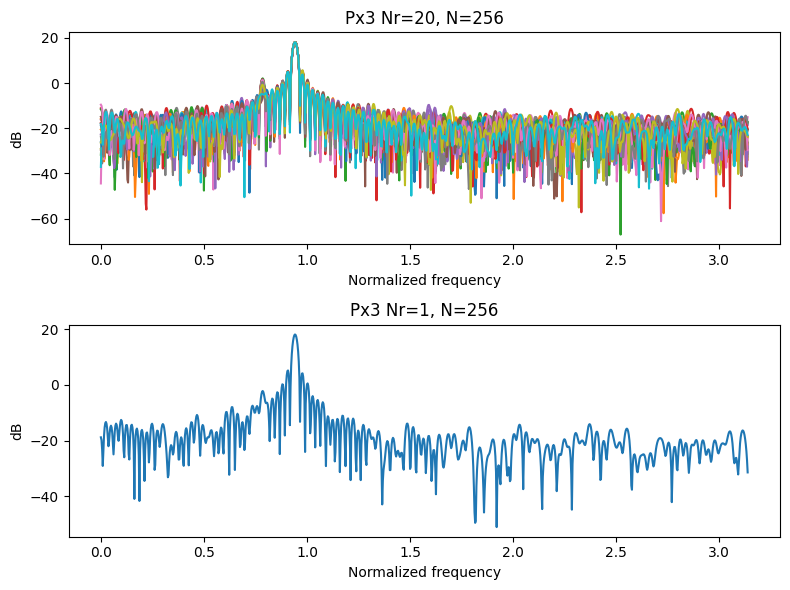

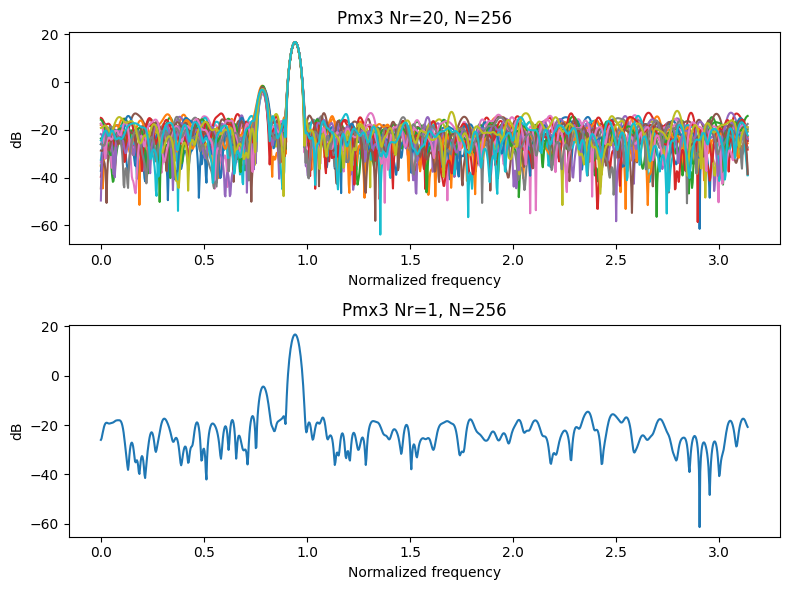

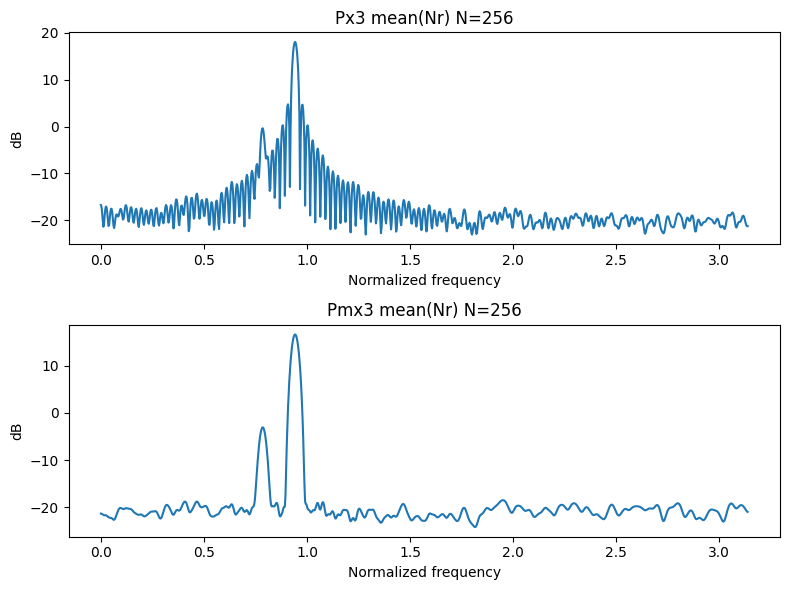

In [50]:
# ==========================================
# 1. Calculs pour toutes les réalisations
# ==========================================
Px3_all = np.zeros((Nr, NFFT))
Pmx3_all = np.zeros((Nr, NFFT))

for i in range(Nr):
    Px3_all[i, :] = myPer(x3[i, :], NFFT)
    Pmx3_all[i, :] = myMPer(x3[i, :], NFFT)

# ==========================================
# 2. Calcul des moyennes
# ==========================================
Px3_mean = np.mean(Px3_all, axis=0)
Pmx3_mean = np.mean(Pmx3_all, axis=0)

# Axe des fréquences en radians (de 0 à pi)
omega = np.arange(NFFT2) * 2 * np.pi / NFFT

# ==========================================
# 3. Affichage (Reproduction des 3 images)
# ==========================================

# --- Figure 1 : Périodogramme standard (Px3) ---
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

for i in range(Nr):
    ax1.plot(omega, 10 * np.log10(Px3_all[i, :NFFT2] + 1e-12))
ax1.set_title(f'Px3 Nr={Nr}, N={N3}')
ax1.set_xlabel('Normalized frequency')
ax1.set_ylabel('dB')

ax2.plot(omega, 10 * np.log10(Px3_all[0, :NFFT2] + 1e-12)) # Seulement la 1ère réalisation
ax2.set_title(f'Px3 Nr=1, N={N3}')
ax2.set_xlabel('Normalized frequency')
ax2.set_ylabel('dB')

fig1.tight_layout()

# --- Figure 2 : Périodogramme modifié (Pmx3) ---
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(8, 6))

for i in range(Nr):
    ax3.plot(omega, 10 * np.log10(Pmx3_all[i, :NFFT2] + 1e-12))
ax3.set_title(f'Pmx3 Nr={Nr}, N={N3}')
ax3.set_xlabel('Normalized frequency')
ax3.set_ylabel('dB')

ax4.plot(omega, 10 * np.log10(Pmx3_all[0, :NFFT2] + 1e-12)) # Seulement la 1ère réalisation
ax4.set_title(f'Pmx3 Nr=1, N={N3}')
ax4.set_xlabel('Normalized frequency')
ax4.set_ylabel('dB')

fig2.tight_layout()

# --- Figure 3 : Moyennes des périodogrammes ---
fig3, (ax5, ax6) = plt.subplots(2, 1, figsize=(8, 6))

ax5.plot(omega, 10 * np.log10(Px3_mean[:NFFT2] + 1e-12))
ax5.set_title(f'Px3 mean(Nr) N={N3}')
ax5.set_xlabel('Normalized frequency')
ax5.set_ylabel('dB')

ax6.plot(omega, 10 * np.log10(Pmx3_mean[:NFFT2] + 1e-12))
ax6.set_title(f'Pmx3 mean(Nr) N={N3}')
ax6.set_xlabel('Normalized frequency')
ax6.set_ylabel('dB')

fig3.tight_layout()

plt.show()